In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')


from connectivity.connectivity import trace_connectivity, extract_connection_indices, save_descent_paths
from connectivity.plot_results import  plot_saddle_tree_with_function, plot_full_connectivity_tree_style
from test_schwefel.schwefel_function_jax import Schwefel4D, schwefel_loss 

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
critical_points_file = "./critical_points_schwefel_4D.csv"

outdir = './results/'

dataframe = pd.read_csv(critical_points_file, index_col=0)
no_maxima = dataframe["type"]!="maximum"
dataframe = dataframe[no_maxima]

saddles_df = dataframe[dataframe["type"] == "saddle"]
minima_df = dataframe[dataframe["type"] == "minimum"]
# minima_df = dataframe[dataframe["type"] != "maximum"]

build_schwefel = lambda p: Schwefel4D(*p)

display(dataframe)

,x1,x2,x3,x4,f_value,type,cp_index
0,0.341809,0.824375,0.824375,0.034551,0.572488,minimum,0
1,0.034551,0.034551,0.034551,0.034551,1.421392,minimum,0
2,0.341810,0.034551,0.034551,0.341809,1.144975,minimum,0
3,0.034551,0.824375,0.341809,0.341809,0.789627,minimum,0
4,0.824375,0.034551,0.824375,0.341809,0.572488,minimum,0
...,...,...,...,...,...,...,...
601,0.824375,0.034551,0.561167,0.824375,1.074875,saddle,1
602,0.034551,0.034551,0.824375,0.561167,1.430223,saddle,1
603,0.034551,0.166287,0.561167,0.034551,1.972082,saddle,2
604,0.166287,0.561167,0.034551,0.824375,1.616734,saddle,2


In [3]:
all_results, minima, dataframe = trace_connectivity(saddles_df,
                                                           minima_df,
                                                           dataframe,
                                                           schwefel_loss,
                                                           build_schwefel,
                                                           [],
                                                           optimizer='gd',
                                                           log_paths=False)


Tracing saddle:  80
Offset 0: [0.56136149 0.82437499 0.34180945 0.56116652]
converged:  True
Offset 1: [0.56116652 0.82437499 0.34180945 0.56136149]
converged:  True
Offset 2: [0.56097156 0.82437499 0.34180945 0.56116652]
converged:  True
Offset 3: [0.56116652 0.82437499 0.34180945 0.56097156]
converged:  True

Tracing saddle:  81
Offset 0: [0.16647893 0.34180945 0.34180945 0.82437499]
converged:  True
Offset 1: [0.16609599 0.34180945 0.34180945 0.82437499]
converged:  True

Tracing saddle:  82
Offset 0: [0.03455081 0.56136149 0.03455081 0.82437499]
converged:  True
Offset 1: [0.03455081 0.56097156 0.03455081 0.82437499]
converged:  True

Tracing saddle:  83
Offset 0: [0.34180946 0.03455081 0.56116652 0.16647892]
converged:  True
Offset 1: [0.34180946 0.03455081 0.56136148 0.16628746]
converged:  True
Offset 2: [0.34180946 0.03455081 0.56116652 0.16609599]
converged:  True
Offset 3: [0.34180946 0.03455081 0.56097155 0.16628746]
converged:  True

Tracing saddle:  84
Offset 0: [0.341809

In [ ]:
# save_descent_paths(paths, out_dir=outdir+'descent_paths/')

# build and save connectivity graph
connectivity_df = extract_connection_indices(all_results, dataframe)
output_file=f'{outdir}/connectivity_graph.csv'
connectivity_df.to_csv(output_file, index=False)

index_map [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

In [3]:
# compute and save merge tree
from connectivity.merge_tree_calc import merge_tree
connectivity_file=f'{outdir}/connectivity_graph.csv'
connectivity_df = pd.read_csv(connectivity_file)
df_tree_nodes, df_tree_edges = merge_tree(dataframe, connectivity_df)
df_tree_nodes.to_csv(outdir+"tree_nodes.csv", index=False)
df_tree_edges.to_csv(outdir+"tree_connectivity.csv", index=False)
print(f"Saved tree to {outdir}")

{567: 0, 130: 1, 472: 2, 397: 3, 356: 4, 189: 5, 150: 6, 144: 7, 385: 8, 461: 9, 556: 10, 537: 11, 111: 12, 346: 13, 520: 14, 500: 15, 580: 16, 499: 17, 239: 18, 495: 19, 223: 20, 181: 21, 282: 22, 309: 23, 88: 24, 110: 25, 365: 26, 230: 27, 140: 28, 265: 29, 141: 30, 444: 31, 336: 32, 391: 33, 564: 34, 321: 35, 295: 36, 482: 37, 590: 38, 593: 39, 353: 40, 236: 41, 524: 42, 137: 43, 101: 44, 96: 45, 94: 46, 588: 47, 585: 48, 371: 49, 324: 50, 491: 51, 573: 52, 349: 53, 332: 54, 97: 55, 421: 56, 515: 57, 171: 58, 550: 59, 412: 60, 120: 61, 136: 62, 283: 63, 362: 64, 290: 65, 169: 66, 329: 67, 319: 68, 316: 69, 350: 70, 426: 71, 386: 72, 455: 73, 149: 74, 566: 75, 105: 76, 278: 77, 312: 78, 158: 79, 420: 80, 154: 81, 224: 82, 214: 83, 264: 84, 235: 85, 405: 86, 408: 87, 245: 88, 452: 89, 592: 90, 161: 91, 595: 92, 469: 93, 569: 94, 423: 95, 603: 96, 456: 97, 320: 98, 574: 99, 210: 100, 89: 101, 276: 102, 258: 103, 318: 104, 84: 105, 558: 106, 343: 107, 392: 108, 508: 109, 581: 110, 512: 

/tmp/ipykernel_2777199/2577327665.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


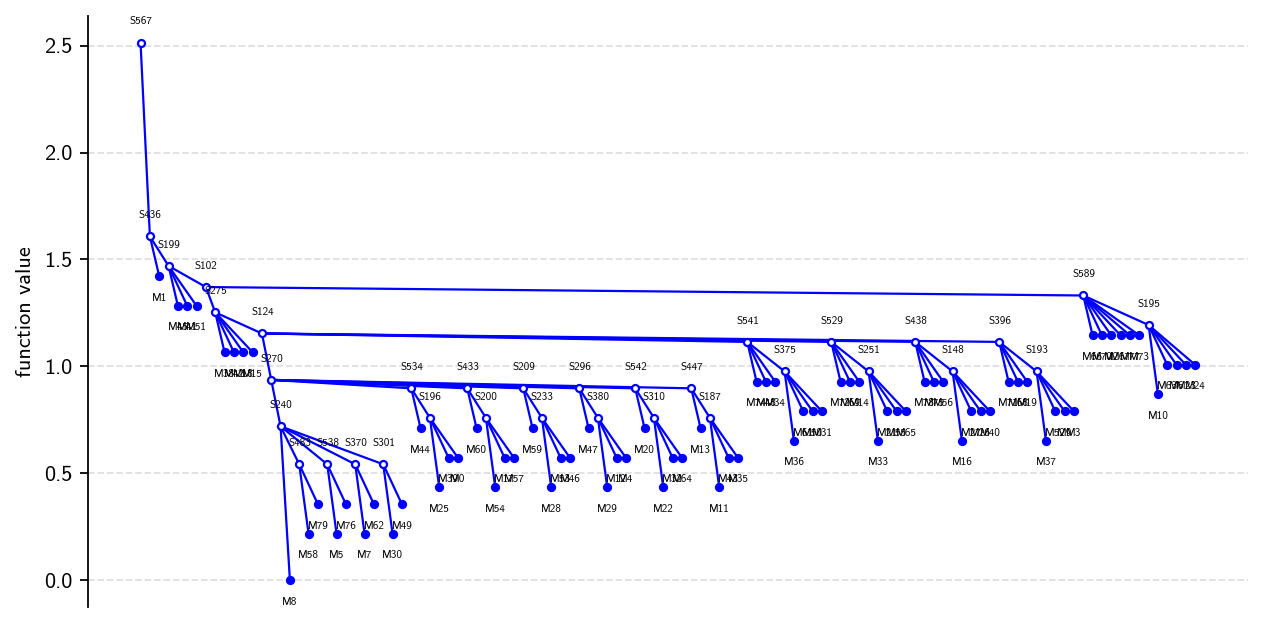

In [4]:
fig1 = plt.figure(figsize=(8,4), dpi=160)

fig1 = plot_saddle_tree_with_function(dataframe, 
                                      nodes_csv="results/tree_nodes.csv",
                                      edges_csv="results/tree_connectivity.csv", 
                                      fig=fig1,
                                      markersize=10,
                                      fontsize=5)

ax = fig1.axes[0]
ax.set_ylabel("function value")
# ax.yaxis.set_major_locator(MaxNLocator(10))
fig1.tight_layout()

fig1.show()
fig1.savefig(outdir+"/tree_plot.png")  # Optional